In [190]:
from __future__ import annotations

import argparse
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from DS_processing import Process_test_DS, Process_train_DS
from sklearn.model_selection import StratifiedKFold

RANDOM_STATE = 42

# 1. Your absolute Mac paths (Keep them strictly uppercase to match the rest of the script)
TRAIN_PATH = "/Users/matteogiardina/Desktop/BEMACS 2/2nd semester/Data/train.csv"
TEST_PATH = "/Users/matteogiardina/Desktop/BEMACS 2/2nd semester/Data/test.csv"
SAMPLE_SUBMISSION_PATH = "/Users/matteogiardina/Desktop/BEMACS 2/2nd semester/Data/submission.csv"

# Optional: Keep the output directory so your feature importance and final CSV save properly
from pathlib import Path
BASE_DIR = Path.cwd()
SUBMISSION_DIR = BASE_DIR / "submissions"
OUTPUT_DIR = BASE_DIR / "outputs"

### Features

In [191]:
BASE_CATEGORICAL_COLS = [
    "Agency",
    "Incident Zip",
    "Police Precinct",
    "Borough",
    "Open Data Channel Type",
    "Problem_Grouped",
    "Location_Grouped",
]

RAW_DETAIL_CATEGORICAL_COLS = [
    "Problem (formerly Complaint Type)",
    "Problem Detail (formerly Descriptor)",
    "Additional Details",
    "Location Type",
    "Address Type",
    "City",
    "Community Board",
    "Council District",
    "Facility Type",
]

CATEGORICAL_COLS = BASE_CATEGORICAL_COLS + RAW_DETAIL_CATEGORICAL_COLS

BASE_NUMERICAL_COLS = [
    "Created_Hour",
    "Created_DayOfWeek",
    "Created_Month",
    "Is_Weekend",
    "Is_Landmark",
    "Is_Taxi",
]

DATE_NUMERICAL_COLS = [
    # "Created_DayOfMonth",
    "Created_Minute",
    "Created_Is_Night",
    "Created_Is_Business_Hours",
]

NUMERICAL_COLS = BASE_NUMERICAL_COLS + DATE_NUMERICAL_COLS

FEATURE_COLS = CATEGORICAL_COLS + NUMERICAL_COLS

In [192]:
def load_raw_data() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load raw CSV files directly from the absolute paths."""
    print("Loading datasets... (This might take a few seconds)")
    
    # Let pandas load them directly. If the path is wrong, pandas will tell you!
    train_raw = pd.read_csv(TRAIN_PATH, index_col=0)
    test_raw = pd.read_csv(TEST_PATH, index_col=0)
    
    # Note: submission.csv usually doesn't have an index column, so we leave index_col=0 out
    sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)
    
    return train_raw, test_raw, sample_submission

In [193]:
def add_raw_features(processed_df: pd.DataFrame, raw_df: pd.DataFrame) -> pd.DataFrame:
    """Add safe raw columns that are available in both train and test."""
    features = processed_df.drop(columns=["Y"], errors="ignore").copy()

    for col in RAW_DETAIL_CATEGORICAL_COLS:
        if col in raw_df.columns:
            features[col] = raw_df.loc[features.index, col]

    if "Created Date" in raw_df.columns:
        created = pd.to_datetime(
            raw_df.loc[features.index, "Created Date"],
            format="%m/%d/%Y %I:%M:%S %p",
            errors="coerce",
        )
        # features["Created_DayOfMonth"] = created.dt.day
        features["Created_Minute"] = created.dt.minute
        features["Created_Is_Night"] = created.dt.hour.isin([0, 1, 2, 3, 4, 5]).astype(int)
        features["Created_Is_Business_Hours"] = (
            (created.dt.hour >= 9)
            & (created.dt.hour <= 17)
            & (~created.dt.dayofweek.isin([5, 6]))
        ).astype(int)

    return features

In [194]:
def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    """Make CatBoost inputs explicit and stable across train, validation, and test."""
    prepared = df.copy()

    for col in CATEGORICAL_COLS:
        if col not in prepared.columns:
            prepared[col] = "Unknown"
        prepared[col] = (
            prepared[col]
            .fillna("Unknown")
            .astype(str)
            .str.replace(r"\.0$", "", regex=True)
        )

    for col in NUMERICAL_COLS:
        if col not in prepared.columns:
            prepared[col] = np.nan
        prepared[col] = pd.to_numeric(prepared[col], errors="coerce")
        if prepared[col].isna().any():
            median = prepared[col].median()
            prepared[col] = prepared[col].fillna(0 if pd.isna(median) else median)

    return prepared[FEATURE_COLS]

In [195]:
def build_feature_frame(processed_df: pd.DataFrame, raw_df: pd.DataFrame) -> pd.DataFrame:
    features = add_raw_features(processed_df, raw_df)
    return prepare_features(features)

In [196]:
def print_dataset_checks(train_df: pd.DataFrame, test_df: pd.DataFrame) -> None:
    print("\nProcessed train info:")
    train_df.info()

    print("\nProcessed test info:")
    test_df.info()

    print("\nNull values in processed train:")
    print(train_df.isna().sum().sort_values(ascending=False))

    print("\nNull values in processed test:")
    print(test_df.isna().sum().sort_values(ascending=False))

    print("\nTarget distribution:")
    print(train_df["Y"].value_counts(normalize=True).round(4))

In [197]:
def build_model(iterations: int, depth: int, learning_rate: float, l2_leaf_reg: float) -> CatBoostClassifier:
    return CatBoostClassifier(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_seed=RANDOM_STATE,
        od_type="Iter",
        od_wait=150,
        allow_writing_files=False,
        verbose=100,
    )

In [198]:
def best_accuracy_threshold(y_true: pd.Series, probabilities: np.ndarray) -> tuple[float, float]:
    thresholds = np.linspace(0.35, 0.65, 301)
    scores = [accuracy_score(y_true, (probabilities >= threshold).astype(int)) for threshold in thresholds]
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])

In [199]:
def save_feature_importance(model: CatBoostClassifier, train_pool: Pool) -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    importance = pd.DataFrame(
        {
            "feature": FEATURE_COLS,
            "importance": model.get_feature_importance(train_pool),
        }
    ).sort_values("importance", ascending=False)

    out_path = OUTPUT_DIR / "catboost_feature_importance.csv"
    # importance.to_csv(out_path, index=False)
    # print(f"\nSaved feature importance to: {out_path}")
    print("\nTop feature importances:")
    print(importance.to_string(index=False))

### Model

In [200]:
## HYPERPARAMETERS
ITERATIONS = 2500
DEPTH = 8
LEARNING_RATE = 0.04
L2_LEAF_REG = 8.0

In [201]:
print("Loading data...")
train_raw, test_raw, sample_submission = load_raw_data()

# 2. Process using your team's pipeline
print("Processing data...")
train_df = Process_train_DS(train_raw.copy())
test_df = Process_test_DS(test_raw.copy())

# 3. Build the final feature frames
X = build_feature_frame(train_df, train_raw)
y = train_df["Y"].astype(int)
X_test = build_feature_frame(test_df, test_raw)

# 4. Print the checks
print_dataset_checks(train_df, test_df)

Loading data...
Loading datasets... (This might take a few seconds)
Processing data...
Dropped 0 rows because their 24-hour window hasn't expired yet.

Processed train info:
<class 'pandas.DataFrame'>
RangeIndex: 110930 entries, 0 to 110929
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Agency                  110930 non-null  str  
 1   Incident Zip            110930 non-null  str  
 2   Police Precinct         110930 non-null  str  
 3   Borough                 110930 non-null  str  
 4   Open Data Channel Type  110930 non-null  str  
 5   Problem_Grouped         110930 non-null  str  
 6   Location_Grouped        110930 non-null  str  
 7   Is_Landmark             110930 non-null  int64
 8   Is_Taxi                 110930 non-null  int64
 9   Created_Hour            110930 non-null  int32
 10  Created_DayOfWeek       110930 non-null  int32
 11  Created_Month           110930 non-null  int3

In [202]:
# # ==========================================
# # HYPERPARAMETER GRID SEARCH
# # ==========================================
# print("Starting Grid Search for optimal hyperparameters...")
# print("(This runs 3-Fold CV internally for every combination, so grab a coffee!)")

# param_grid = {
#     "depth": [6, 8, 10],
#     "learning_rate": [0.03, 0.05, 0.1, 0.12],
#     "l2_leaf_reg": [1, 3, 5, 8],
# }

# # 2. Initialize a base model for the search
# # We lower iterations to 500 here just so the search doesn't take 3 hours
# grid_model = CatBoostClassifier(
#     iterations=500, 
#     loss_function="Logloss",
#     random_seed=RANDOM_STATE,
#     od_type="Iter",
#     od_wait=50,
#     verbose=False
# )

# # 3. Create a master pool of all training data
# grid_pool = Pool(X, y, cat_features=CATEGORICAL_COLS)

# # 4. Run the native CatBoost Grid Search
# grid_search_result = grid_model.grid_search(
#     param_grid, 
#     X=grid_pool, 
#     plot=False,     # Set to True if you want a visual chart in the notebook!
#     verbose=False
# )

# # 5. Extract and print the winners
# best_params = grid_search_result['params']

# print("\n" + "="*40)
# print("BEST HYPERPARAMETERS FOUND:")
# print(f"Depth:         {best_params['depth']}")
# print(f"L2 Leaf Reg:   {best_params['l2_leaf_reg']}")
# print(f"Learning Rate: {best_params['learning_rate']}")
# print("="*40 + "\n")

# # 6. Dynamically update your global variables so the next cell uses them!
# DEPTH = best_params['depth']
# L2_LEAF_REG = best_params['l2_leaf_reg']
# LEARNING_RATE = best_params['learning_rate']

In [203]:
# HYPERPARAMETERS FOUND BY GRID-SEARCH
DEPTH = 10
L2_LEAF_REG = 8
LEARNING_RATE = 0.1

In [204]:
print("Starting 5-Fold Cross Validation...")

# 1. Setup the K-Fold splitter
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Array to store our Out-Of-Fold (OOF) probabilities
oof_probabilities = np.zeros(len(X))
fold_metrics = []
best_iterations = []

# 2. Run the Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    print(f"\n--- Running Fold {fold} / 5 ---")

    # Split data using pandas .iloc to match the K-Fold indices
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Create Pools
    train_pool = Pool(X_train, y_train, cat_features=CATEGORICAL_COLS)
    val_pool = Pool(X_val, y_val, cat_features=CATEGORICAL_COLS)

    # Build and train the model for this fold
    fold_model = build_model(
        iterations=ITERATIONS,
        depth=DEPTH,
        learning_rate=LEARNING_RATE,
        l2_leaf_reg=L2_LEAF_REG
    )

    # Note: verbose=500 keeps your notebook clean by only printing every 500 trees
    fold_model.fit(train_pool, eval_set=val_pool, use_best_model=True, verbose=500) 

    # Predict probabilities for the validation set
    val_probs = fold_model.predict_proba(val_pool)[:, 1]

    # Save the probabilities in our OOF array
    oof_probabilities[val_idx] = val_probs

    # Get fold metrics
    best_iter = fold_model.get_best_iteration()
    best_iterations.append(best_iter)
    
    fold_acc = accuracy_score(y_val, (val_probs >= 0.5).astype(int))
    fold_metrics.append(fold_acc)
    
    print(f"Fold {fold} Base Accuracy: {fold_acc:.5f} (Best Iteration: {best_iter})")

print("\n" + "="*40)
print("CROSS-VALIDATION COMPLETE")
print(f"Average Base CV Accuracy: {np.mean(fold_metrics):.5f} (+/- {np.std(fold_metrics):.5f})")
print("="*40)
print(f"Best iterations per fold: {best_iterations}")
AVG_BEST_ITER = int(np.mean(best_iterations))
print(f"Average best iteration: {AVG_BEST_ITER}")

Starting 5-Fold Cross Validation...

--- Running Fold 1 / 5 ---
0:	learn: 0.8691517	test: 0.8674389	best: 0.8674389 (0)	total: 162ms	remaining: 6m 45s
500:	learn: 0.9596029	test: 0.8971423	best: 0.8982692 (371)	total: 48.2s	remaining: 3m 12s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.8982691788
bestIteration = 371

Shrink model to first 372 iterations.
Fold 1 Base Accuracy: 0.89827 (Best Iteration: 371)

--- Running Fold 2 / 5 ---
0:	learn: 0.8758113	test: 0.8815018	best: 0.8815018 (0)	total: 88ms	remaining: 3m 39s
500:	learn: 0.9547688	test: 0.9026864	best: 0.9034977 (421)	total: 49.7s	remaining: 3m 18s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.9034977013
bestIteration = 421

Shrink model to first 422 iterations.
Fold 2 Base Accuracy: 0.90350 (Best Iteration: 421)

--- Running Fold 3 / 5 ---
0:	learn: 0.8754733	test: 0.8761832	best: 0.8761832 (0)	total: 76.7ms	remaining: 3m 11s
Stopped by overfitting detector  (150 iterations wait)


In [205]:
print("Tuning Threshold on Out-Of-Fold Predictions...")

# 1. Calculate the absolute best threshold across all 5 folds
tuned_threshold, tuned_accuracy = best_accuracy_threshold(y, oof_probabilities)
oof_predictions = (oof_probabilities >= tuned_threshold).astype(int)

# 2. Print Final Results
print("-" * 40)
print("FINAL TUNED OOF RESULTS:")
print(f"Best Global Threshold:   {tuned_threshold:.3f}")
print(f"Tuned OOF Accuracy:      {tuned_accuracy:.5f}")
print(f"Average Best Iteration:  {int(np.mean(best_iterations))}")
print("-" * 40)

print("\nClassification Report (Tuned OOF):")
print(classification_report(y, oof_predictions, target_names=["Not closed in 24h", "Closed in 24h"]))

print("\nConfusion Matrix (Tuned OOF):")
print(confusion_matrix(y, oof_predictions))

# 3. Save Feature Importance (We use the very last fold's model as a proxy, 
# as feature importance is usually nearly identical across folds)
save_feature_importance(fold_model, train_pool)

Tuning Threshold on Out-Of-Fold Predictions...
----------------------------------------
FINAL TUNED OOF RESULTS:
Best Global Threshold:   0.500
Tuned OOF Accuracy:      0.90093
Average Best Iteration:  319
----------------------------------------

Classification Report (Tuned OOF):
                   precision    recall  f1-score   support

Not closed in 24h       0.85      0.90      0.88     42833
    Closed in 24h       0.94      0.90      0.92     68097

         accuracy                           0.90    110930
        macro avg       0.89      0.90      0.90    110930
     weighted avg       0.90      0.90      0.90    110930


Confusion Matrix (Tuned OOF):
[[38628  4205]
 [ 6785 61312]]

Top feature importances:
                             feature  importance
                              Agency    9.677767
                   Created_DayOfWeek    9.384413
   Problem (formerly Complaint Type)    8.143109
                        Created_Hour    7.825585
                           

/var/folders/kl/1mbq_bq901b23w9l67rfnn0c0000gn/T/ipykernel_76779/3023122861.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


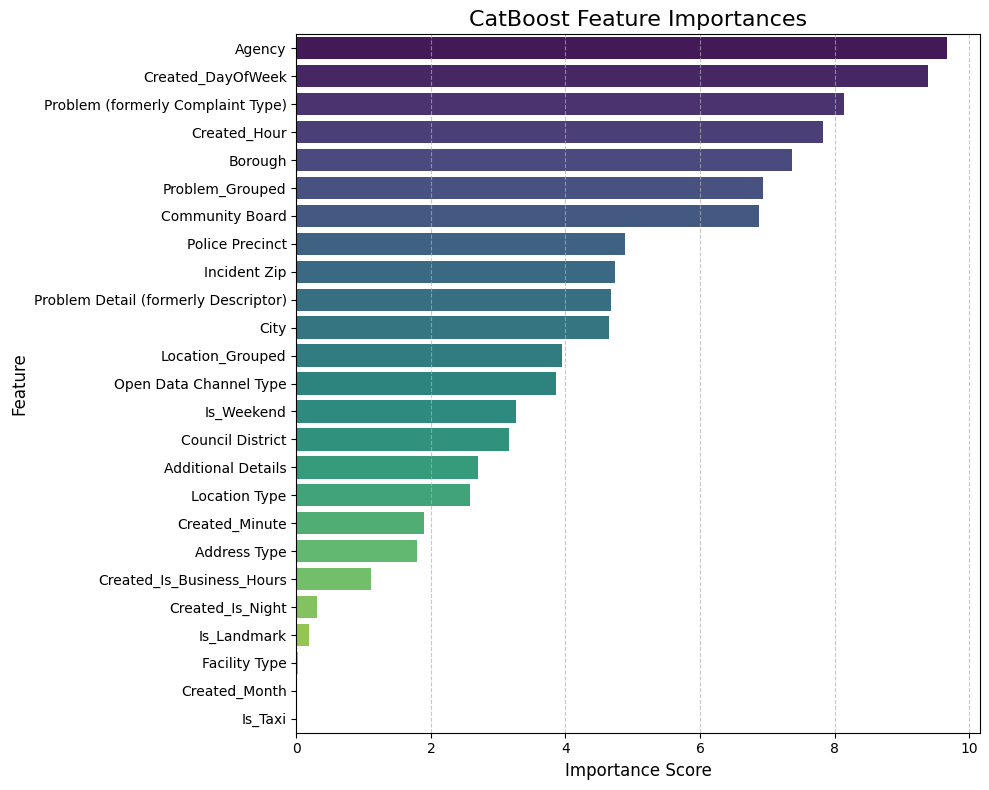

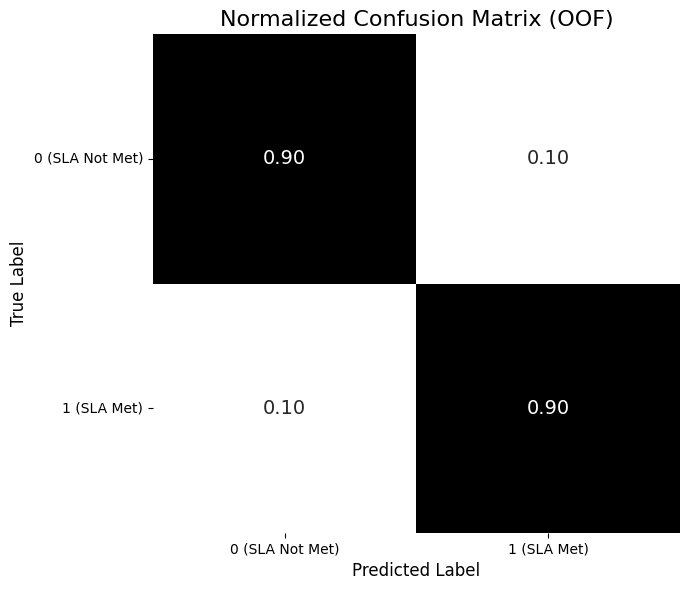

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. Plot Feature Importances (Horizontal)
# ==========================================
# Extract importances from the final fold_model
importance_scores = fold_model.get_feature_importance(train_pool)
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS, 
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

# Create the plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title('CatBoost Feature Importances', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("feature_importances.png", dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# 2. Plot Normalized Confusion Matrix
# ==========================================
# Calculate the normalized confusion matrix (rows sum to 1)
cm_normalized = confusion_matrix(y, oof_predictions, normalize='true')

# Create the plot
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt=".2f",      # Format as 2 decimal places
    cmap="bone_r",  # Dark teal/gray color map similar to the example
    xticklabels=["0 (SLA Not Met)", "1 (SLA Met)"],
    yticklabels=["0 (SLA Not Met)", "1 (SLA Met)"],
    annot_kws={"size": 14},
    cbar=False      # Hide the color bar for a cleaner look
)

plt.title('Normalized Confusion Matrix (OOF)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.yticks(rotation=0) 
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [207]:
# -----------------------------
# Final training
# -----------------------------

FINAL_THRESHOLD = 0.5  # from CV

final_cat_cols = [c for c in CATEGORICAL_COLS if c in X.columns]

train_pool = Pool(X, y, cat_features=final_cat_cols)
test_pool = Pool(X_test, cat_features=final_cat_cols)

final_model = CatBoostClassifier(
    iterations=AVG_BEST_ITER,
    depth=DEPTH,
    learning_rate=LEARNING_RATE,
    l2_leaf_reg=L2_LEAF_REG,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=200
)

final_model.fit(train_pool)

# -----------------------------
# Predictions
# -----------------------------

test_proba = final_model.predict_proba(test_pool)[:, 1]
test_pred = (test_proba >= FINAL_THRESHOLD).astype(int)

# -----------------------------
# Submission (ONLY predictions)
# -----------------------------

submission = pd.DataFrame(test_pred, columns=["prediction"])

submission.to_csv("submission.csv", index=False)

print("Saved submission.csv")
print(submission.head())

# Proportion of predictions
prop_1 = test_pred.mean()
prop_0 = 1 - prop_1

print(f"Proportion of class 1: {prop_1:.4f}")
print(f"Proportion of class 0: {prop_0:.4f}")

0:	learn: 0.8709366	total: 100ms	remaining: 31.9s
200:	learn: 0.9210583	total: 27.3s	remaining: 16s
318:	learn: 0.9353827	total: 42.5s	remaining: 0us
Saved submission.csv
   prediction
0           1
1           0
2           0
3           1
4           0
Proportion of class 1: 0.5894
Proportion of class 0: 0.4106


### Run model only on preprocessed features

In [208]:
train_raw, test_raw, sample_submission = load_raw_data()

train_df = Process_train_DS(train_raw.copy())
test_df = Process_test_DS(test_raw.copy())

# 3. Build the final feature frames
X = train_df.drop(columns=["Y"])
y = train_df["Y"].astype(int)
X_test = test_df.copy()

Loading datasets... (This might take a few seconds)
Dropped 0 rows because their 24-hour window hasn't expired yet.


In [209]:
print("Starting 5-Fold Cross Validation...")

# 1. Setup the K-Fold splitter
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Array to store our Out-Of-Fold (OOF) probabilities
oof_probabilities = np.zeros(len(X))
fold_metrics = []
best_iterations = []

# 2. Run the Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    print(f"\n--- Running Fold {fold} / 5 ---")

    # Split data using pandas .iloc to match the K-Fold indices
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    cat_cols_fold = [c for c in CATEGORICAL_COLS if c in X_train.columns]

    # Create Pools
    train_pool = Pool(X_train, y_train, cat_features=cat_cols_fold)
    val_pool = Pool(X_val, y_val, cat_features=cat_cols_fold)

    # Build and train the model for this fold
    fold_model = build_model(
        iterations=ITERATIONS,
        depth=DEPTH,
        learning_rate=LEARNING_RATE,
        l2_leaf_reg=L2_LEAF_REG
    )

    # Note: verbose=500 keeps your notebook clean by only printing every 500 trees
    fold_model.fit(train_pool, eval_set=val_pool, use_best_model=True, verbose=500) 

    # Predict probabilities for the validation set
    val_probs = fold_model.predict_proba(val_pool)[:, 1]

    # Save the probabilities in our OOF array
    oof_probabilities[val_idx] = val_probs

    # Get fold metrics
    best_iter = fold_model.get_best_iteration()
    best_iterations.append(best_iter)
    
    fold_acc = accuracy_score(y_val, (val_probs >= 0.5).astype(int))
    fold_metrics.append(fold_acc)
    
    print(f"Fold {fold} Base Accuracy: {fold_acc:.5f} (Best Iteration: {best_iter})")

print("\n" + "="*40)
print("CROSS-VALIDATION COMPLETE")
print(f"Average Base CV Accuracy: {np.mean(fold_metrics):.5f} (+/- {np.std(fold_metrics):.5f})")
print("="*40)

Starting 5-Fold Cross Validation...

--- Running Fold 1 / 5 ---
0:	learn: 0.8623907	test: 0.8611737	best: 0.8611737 (0)	total: 71.9ms	remaining: 2m 59s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.8771747949
bestIteration = 260

Shrink model to first 261 iterations.
Fold 1 Base Accuracy: 0.87717 (Best Iteration: 260)

--- Running Fold 2 / 5 ---
0:	learn: 0.8632809	test: 0.8664022	best: 0.8664022 (0)	total: 45.2ms	remaining: 1m 52s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.883034346
bestIteration = 194

Shrink model to first 195 iterations.
Fold 2 Base Accuracy: 0.88303 (Best Iteration: 194)

--- Running Fold 3 / 5 ---
0:	learn: 0.8626949	test: 0.8644641	best: 0.8644641 (0)	total: 55.2ms	remaining: 2m 17s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.8810060398
bestIteration = 281

Shrink model to first 282 iterations.
Fold 3 Base Accuracy: 0.88101 (Best Iteration: 281)

--- Running Fold 4 / 5 ---
0:	learn: 0.8651